In [1]:
## libraries needs to run the script ##
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [7]:
def count_clusters(xtc_file=["equil4-pbc.xtc", "equil5-pbc.xtc","equil6-pbc.xtc","equil7-pbc.xtc", "equil8-pbc.xtc"],  
                   tpr_file="equil4.tpr", 
                   atom_selection='resname LIG and name PO', 
                   eps=4.7, 
                   min_samples=3, 
                   output_file="cluster_counts.csv"):

    u = mda.Universe(tpr_file, xtc_file, in_memory=True, in_memory_step=200)
    sel_atoms = u.select_atoms(atom_selection)

    cluster_counts = []
    times = []

    for ts in u.trajectory:
        positions = sel_atoms.positions
        clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(positions)
        n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
        cluster_counts.append(n_clusters)
        times.append(ts.time / 1000)  # convert ps to ns

    times = np.array(times)
    cluster_counts = np.array(cluster_counts)

    # Save to CSV
    np.savetxt(output_file, 
               np.column_stack((times, cluster_counts)), 
               delimiter=",", 
               header="Time(ns),Clusters", 
               comments='')

    print(f"Cluster counts saved to '{output_file}'")

    return times, cluster_counts

# Example call
times, cluster_counts = count_clusters()

Cluster counts saved to 'cluster_counts.csv'


In [10]:
u = mda.Universe("equil4.tpr", "equil4-pbc.xtc", in_memory=True, in_memory_step=50)
##print(u.atoms)
print(u.atoms.positions)

[[184.9      174.65      99.7     ]
 [187.25     176.       100.99999 ]
 [189.04999  178.85     100.      ]
 ...
 [103.49999  102.649994 203.54999 ]
 [103.6      101.75     201.84999 ]
 [103.       103.899994 204.84999 ]]


In [11]:
u.atoms.positions

array([[184.9     , 174.65    ,  99.7     ],
       [187.25    , 176.      , 100.99999 ],
       [189.04999 , 178.85    , 100.      ],
       ...,
       [103.49999 , 102.649994, 203.54999 ],
       [103.6     , 101.75    , 201.84999 ],
       [103.      , 103.899994, 204.84999 ]], dtype=float32)

In [31]:
import MDAnalysis as mda
import numpy as np
from sklearn.cluster import DBSCAN

def count_clusters(xtc_file=["equil4-pbc.xtc", "equil5-pbc.xtc", "equil6-pbc.xtc", "equil7-pbc.xtc", "equil8-pbc.xtc"],  
                   tpr_file="equil4.tpr", 
                   atom_selection='resname LIG and name PO', 
                   eps=4.7, 
                   min_samples=3, 
                   output_file="cluster_counts.csv"):

    u = mda.Universe(tpr_file, xtc_file, in_memory=True, in_memory_step=200)
    sel_atoms = u.select_atoms(atom_selection)

    cluster_counts = []
    times = []

    # Manual time axis calculation: 20 ns per analyzed frame
    frame_interval_ns = 200 * 10000 * 0.01 / 1000  # = 20 ns

    for i, ts in enumerate(u.trajectory):
        positions = sel_atoms.positions
        clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(positions)
        n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
        cluster_counts.append(n_clusters)
        times.append(i * frame_interval_ns)

    times = np.array(times)
    cluster_counts = np.array(cluster_counts)

    # Save to CSV
    np.savetxt(output_file, 
               np.column_stack((times, cluster_counts)), 
               delimiter=",", 
               fmt="%.8e", 
               header="Time(ns),Clusters", 
               comments='')

    print(f"Cluster counts saved to '{output_file}'")

    return times, cluster_counts

# Example call
times, cluster_counts = count_clusters()


KeyboardInterrupt: 

In [221]:
import MDAnalysis as mda
import numpy as np
from sklearn.cluster import DBSCAN

def count_clusters(xtc_file=["equil4-pbc.xtc"],  
                   tpr_file="equil4.tpr", 
                   atom_selection='resname LIG and name PO', 
                   eps=4.7, 
                   min_samples=3, 
                   output_file="cluster_counts-equil4.csv"):

    u = mda.Universe(tpr_file, xtc_file, in_memory=True, in_memory_step=100)
    sel_atoms = u.select_atoms(atom_selection)

    cluster_counts = []
    times = []

    # Manual time axis calculation: 20 ns per analyzed frame
    frame_interval_ns = 100 * 200 * 0.01 / 1000  # = 20 ns

    for i, ts in enumerate(u.trajectory):
        positions = sel_atoms.positions
        clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(positions)
        n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
        cluster_counts.append(n_clusters)
        times.append(i * frame_interval_ns)

    times = np.array(times)
    cluster_counts = np.array(cluster_counts)

    # Save to CSV
    np.savetxt(output_file, 
               np.column_stack((times, cluster_counts)), 
               delimiter="  ", 
               fmt="%.8e", 
               header="Time(ns),Clusters", 
               comments='')

    print(f"Cluster counts saved to '{output_file}'")

    return times, cluster_counts

# Example call
times, cluster_counts = count_clusters()


Cluster counts saved to 'cluster_counts-equil4.csv'


In [17]:
import MDAnalysis as mda
import numpy as np
from sklearn.cluster import DBSCAN

def count_clusters(xtc_file=["equil5-pbc.xtc", "equil6-pbc.xtc", "equil7-pbc.xtc", "equil8-pbc.xtc", "equil9-pbc.xtc","equil10-pbc.xtc", "equil11-pbc.xtc"],  
                   tpr_file="equil5.tpr", 
                   atom_selection='resname LIG and name PO', 
                   eps=4.7, 
                   min_samples=3, 
                   output_file="cluster_counts.csv"):

    u = mda.Universe(tpr_file, xtc_file, in_memory=True, in_memory_step=100)
    sel_atoms = u.select_atoms(atom_selection)

    cluster_counts = []
    times = []

    # Manual time axis calculation: 20 ns per analyzed frame
    frame_interval_ns = 100 * 1000 * 0.01 / 1000  # = 20 ns

    for i, ts in enumerate(u.trajectory):
        positions = sel_atoms.positions
        clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(positions)
        n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
        cluster_counts.append(n_clusters)
        times.append(i * frame_interval_ns+50)

    times = np.array(times)
    cluster_counts = np.array(cluster_counts)

    # Save to CSV
    np.savetxt(output_file, 
               np.column_stack((times, cluster_counts)), 
               delimiter="  ", 
               fmt="%.8e", 
               header="Time(ns),Clusters", 
               comments='')

    print(f"Cluster counts saved to '{output_file}'")

    return times, cluster_counts

# Example call
times, cluster_counts = count_clusters()


Cluster counts saved to 'cluster_counts.csv'


In [2]:
import pandas as pd
# Load both CSV files (skip headers)
data1 = pd.read_csv ("cluster_counts-equil4.csv", sep=r'\s+', skiprows=1, names=["time", "Clusters"])
data2 = pd.read_csv("cluster_counts.csv", sep=r'\s+', skiprows=1, names=["time", "Clusters"])
data3 = pd.read_csv("../../../Solvation-free-energy/phase-seperation-pluronic-emim-dca/folder-330K/cluster_counts-equil4.csv", sep=r'\s+', skiprows=1, names=["time", "Clusters"])
data4 = pd.read_csv("../../../Solvation-free-energy/phase-seperation-pluronic-emim-dca/folder-330K/cluster_counts.csv", sep=r'\s+', skiprows=1, names=["time", "Clusters"])

In [2]:
data2

,time,Clusters
0,50.0,4.0
1,51.0,4.0
2,52.0,4.0
3,53.0,4.0
4,54.0,4.0
...,...,...
1196,1246.0,3.0
1197,1247.0,3.0
1198,1248.0,3.0
1199,1249.0,3.0


In [3]:
## concat two CVS file and plot them together ##
df= pd.concat([data1, data2])
df_330K = pd.concat([data3, data4])

In [4]:
df

,time,Clusters
0,0.0,22.0
1,0.2,17.0
2,0.4,17.0
3,0.6,15.0
4,0.8,15.0
...,...,...
1196,1246.0,3.0
1197,1247.0,3.0
1198,1248.0,3.0
1199,1249.0,3.0


In [144]:
df.to_csv('filen_new.csv')
file1 = pd.read_csv("filen_new.csv", names= ["time", "cluster"], skiprows=1, delim_whitespace=True)

/tmp/ipykernel_413832/1581589959.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  file1 = pd.read_csv("filen_new.csv", names= ["time", "cluster"], skiprows=1, delim_whitespace=True)


In [127]:
file1['time']

0          0,0.00000000e+00
1          1,1.00000000e-01
2          2,2.00000000e-01
3          3,3.00000000e-01
4          4,4.00000000e-01
               ...         
2097    1596,8.48000000e+02
2098    1597,8.48500000e+02
2099    1598,8.49000000e+02
2100    1599,8.49500000e+02
2101    1600,8.50000000e+02
Name: time, Length: 2102, dtype: object

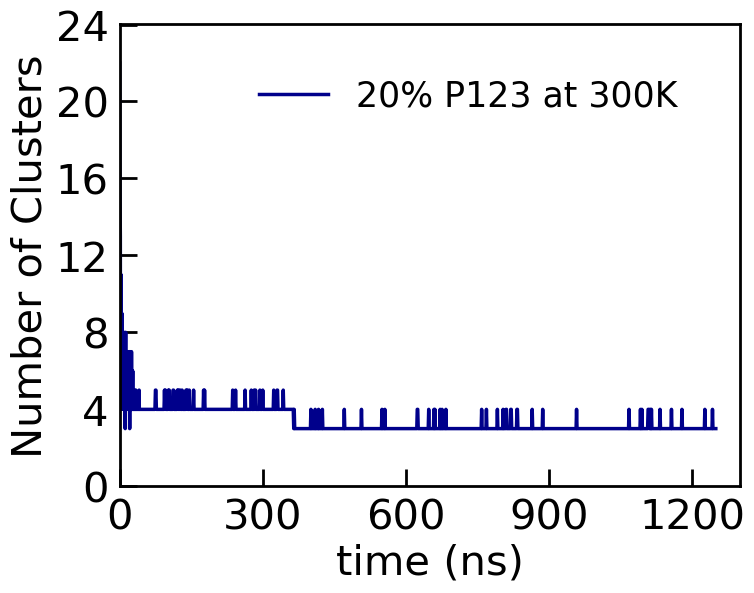

In [29]:
## Plot the data of cluster vs time at 300 and 330 K ##
from pylab import rc
## Graph plot ##
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
rc('axes', linewidth=2.0)
#plt.figure(figsize=(10, 6))
plt.plot(df["time"], df["Clusters"], linestyle='-', color='darkblue', label="20% P123 at 300K",linewidth=2.5)
#plt.plot(df_330K["time"], df_330K["Clusters"], linestyle='-', color='darkred', label="T=330K",linewidth=2.5)
plt.xlabel("time (ns)", fontsize=30, fontname='DejaVu Sans')
plt.ylabel("Number of Clusters", fontsize=30, fontname='DejaVu Sans')
#plt.title("Number of Clusters vs Time", fontsize=25, fontname='DejaVu Sans')
#plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0,1300.01)
plt.ylim(0, 24.01)
plt.xticks(np.arange(0, 1300.001, 300), fontsize=22, fontname='DejaVu Sans')
plt.yticks(np.arange(0, 24.001, 4), fontsize=22, fontname='DejaVu Sans')

# Legend and formatting
plt.legend(fontsize=25, bbox_to_anchor=(0.95, 0.95), loc='upper right', edgecolor='white')
plt.tick_params(axis='both', which='major', length=12, direction='in', width=2, labelsize=30, pad=8)

#plt.yticks(np.arange(0, 25.001, 5), fontsize=40, fontname='DejaVu Sans')
##plt.tight_layout()
plt.savefig("cluster-20per-pluro-300K.png", bbox_inches='tight', dpi=500)
plt.show()

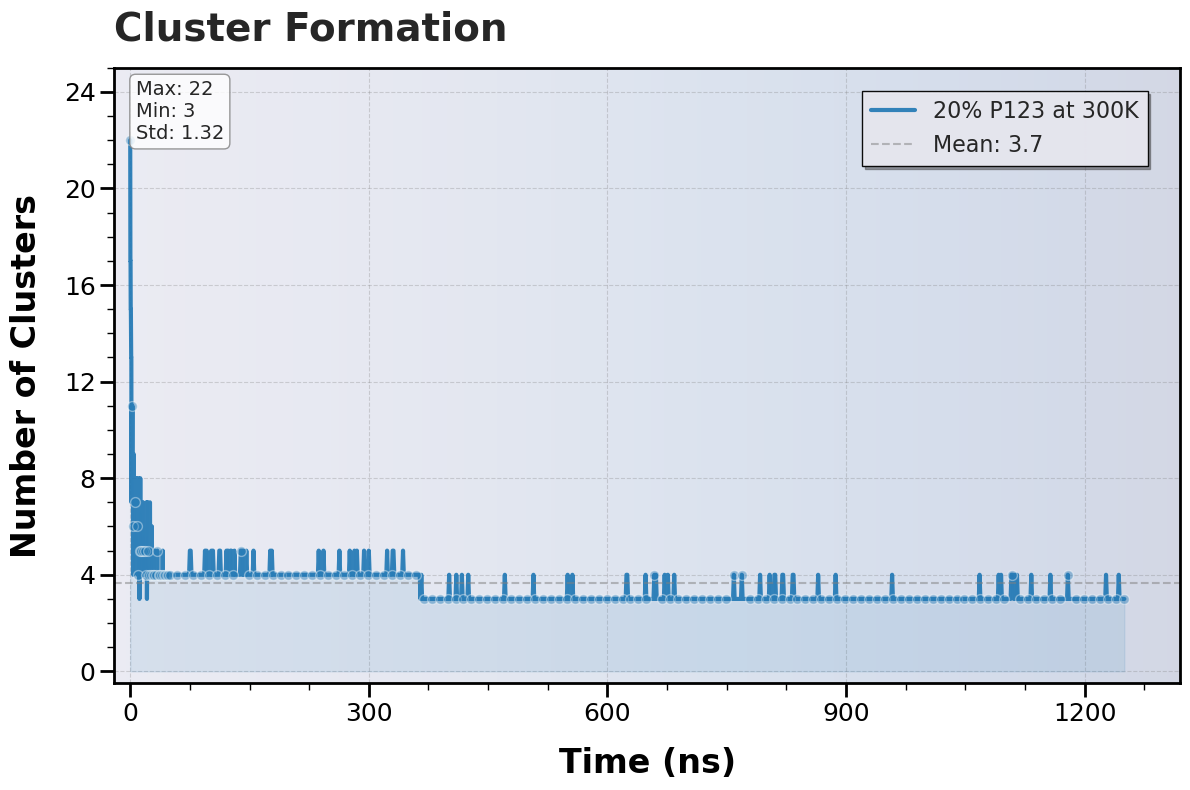

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
import matplotlib.gridspec as gridspec

# Set global style parameters for a publication-quality figure
plt.style.use('seaborn-v0_8-darkgrid')  # Use a modern style
rcParams['font.family'] = 'DejaVu Sans'
rcParams['axes.linewidth'] = 2
rcParams['axes.edgecolor'] = 'black'
rcParams['axes.labelcolor'] = 'black'
rcParams['xtick.color'] = 'black'
rcParams['ytick.color'] = 'black'
rcParams['legend.frameon'] = True
rcParams['legend.framealpha'] = 0.9
rcParams['legend.edgecolor'] = 'black'

# Create figure with subplots
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 1, figure=fig)

# Main plot
ax = fig.add_subplot(gs[0])

# Plot with enhanced styling
line1 = ax.plot(df["time"], df["Clusters"], 
                linestyle='-', 
                color='#1f77b4',  # Professional blue
                label="20% P123 at 300K",
                linewidth=3,
                alpha=0.9,
                zorder=2)

# Add data points with transparency
ax.scatter(df["time"][::10], df["Clusters"][::10],  # Plot every 10th point to avoid overcrowding
           color='#1f77b4',
           s=50,
           alpha=0.4,
           edgecolors='white',
           linewidth=1,
           zorder=3)

# Fill under the curve for visual interest
ax.fill_between(df["time"], 0, df["Clusters"], 
                alpha=0.1, 
                color='#1f77b4',
                zorder=1)

# Add mean line
mean_value = df["Clusters"].mean()
ax.axhline(y=mean_value, 
           color='gray', 
           linestyle='--', 
           linewidth=1.5, 
           alpha=0.5,
           label=f'Mean: {mean_value:.1f}')

# Customize axes
ax.set_xlabel("Time (ns)", fontsize=24, fontweight='bold', labelpad=15)
ax.set_ylabel("Number of Clusters", fontsize=24, fontweight='bold', labelpad=15)

# Set limits with some padding
ax.set_xlim(-20, 1320)  # Slight padding
ax.set_ylim(-0.5, 25)

# Custom ticks
ax.set_xticks(np.arange(0, 1301, 300))
ax.set_yticks(np.arange(0, 25, 4))
ax.tick_params(axis='both', which='major', length=10, width=2, labelsize=18)

# Add minor ticks for better readability
ax.tick_params(axis='both', which='minor', length=5, width=1)
ax.minorticks_on()

# Enhanced legend
legend = ax.legend(fontsize=16, 
                  loc='upper right',
                  bbox_to_anchor=(0.98, 0.98),
                  framealpha=0.95,
                  edgecolor='black',
                  fancybox=False,
                  shadow=True)

# Add text annotation for key statistics
stats_text = f'Max: {df["Clusters"].max():.0f}\nMin: {df["Clusters"].min():.0f}\nStd: {df["Clusters"].std():.2f}'
ax.text(0.02, 0.98, stats_text, 
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# Add grid with custom styling
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.8, color='gray')

# Add a subtle gradient background
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax.imshow(gradient, extent=[ax.get_xlim()[0], ax.get_xlim()[1], 
                            ax.get_ylim()[0], ax.get_ylim()[1]], 
          aspect='auto', cmap='Blues', alpha=0.1, zorder=0)

# Add title with improved styling
ax.set_title("Cluster Formation", fontsize=28, fontweight='bold', pad=20, loc='left')

# Save with high quality
plt.tight_layout()
plt.savefig('cluster_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('cluster_analysis.pdf', bbox_inches='tight')  # Vector format for publications
plt.savefig('cluster_analysis.svg', bbox_inches='tight')  # SVG for web

plt.show()

In [6]:
import json

# Export data for D3.js
data_for_d3 = {
    "data": [
        {"time": t, "clusters": c} 
        for t, c in zip(df["time"].tolist(), df["Clusters"].tolist())
    ],
    "metadata": {
        "title": "Number of Clusters vs Time",
        "xlabel": "Time (ns)",
        "ylabel": "Number of Clusters",
        "temperature": "300K",
        "condition": "20% P123"
    }
}

# Save as JSON for D3.js
with open('cluster_data.json', 'w') as f:
    json.dump(data_for_d3, f, indent=2)

print("Data exported to cluster_data.json for D3.js visualization")

Data exported to cluster_data.json for D3.js visualization


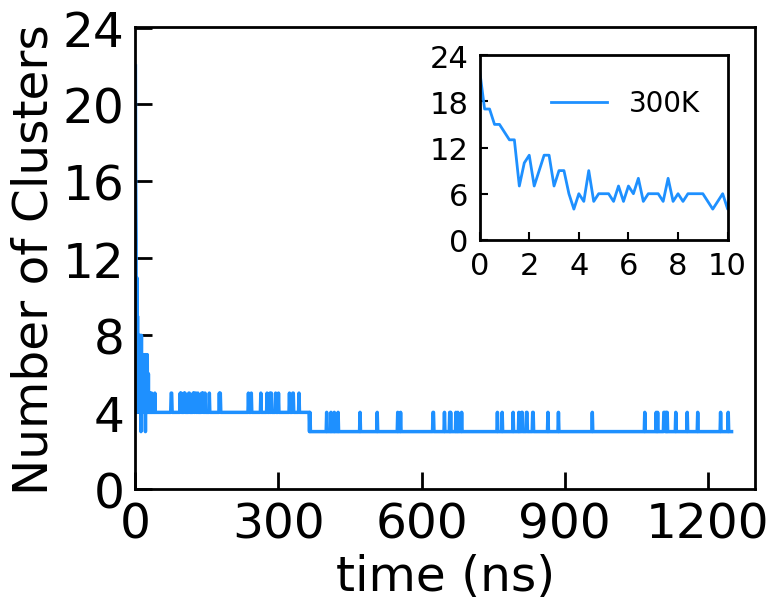

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from pylab import rc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Set plot styling
rc('axes', linewidth=2.0)

# Create main plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(df["time"], df["Clusters"], linestyle='-', color='dodgerblue', linewidth=2.5)

# Labels and ticks
ax.set_xlabel("time (ns)", fontsize=35, fontname='DejaVu Sans')
ax.set_ylabel("Number of Clusters", fontsize=35, fontname='DejaVu Sans')
ax.set_xlim(0, 1300.01)
ax.set_ylim(0, 24.01)
ax.set_xticks(np.arange(0, 1300.001, 300))
ax.set_yticks(np.arange(0, 24.001, 4))
ax.tick_params(axis='both', which='major', length=12, direction='in', width=2, labelsize=35, pad=8)

# Create inset plot in the upper right corner
ax_inset = inset_axes(ax, width="40%", height="40%", loc='upper right', borderpad=2)

# Plot the same data in the inset, zoomed into the first 50 ns
ax_inset.plot(df["time"], df["Clusters"], linestyle='-', color='dodgerblue', linewidth=2.0, label="300K")
ax_inset.set_xlim(0, 10)
ax_inset.set_ylim(0, 24)
ax_inset.set_xticks([0, 2, 4, 6, 8, 10])
ax_inset.set_yticks([0, 6, 12, 18, 24])
ax_inset.tick_params(axis='both', which='major', length=6, direction='in', width=1.5, labelsize=22, pad=8)
plt.legend(fontsize=20, bbox_to_anchor=(0.99, 0.95), loc='upper right', edgecolor='white')
# Save and show
plt.savefig("cluster-20per-pluro-300K-with-inset.png", bbox_inches='tight', dpi=500)
plt.show()

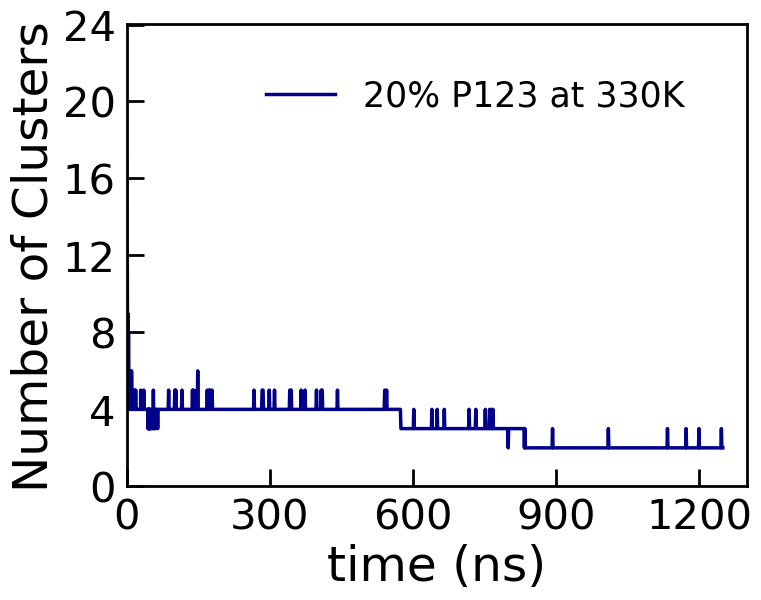

In [17]:
## Plot the data of cluster vs time at 300 and 330 K ##
from pylab import rc
## Graph plot ##
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
rc('axes', linewidth=2.0)
#plt.figure(figsize=(10, 6))
plt.plot(df_330K["time"], df_330K["Clusters"], linestyle='-', color='darkblue', label="20% P123 at 330K",linewidth=2.5)
#plt.plot(df_330K["time"], df_330K["Clusters"], linestyle='-', color='darkred', label="T=330K",linewidth=2.5)
plt.xlabel("time (ns)", fontsize=35, fontname='DejaVu Sans')
plt.ylabel("Number of Clusters", fontsize=35, fontname='DejaVu Sans')
#plt.title("Number of Clusters vs Time", fontsize=25, fontname='DejaVu Sans')
#plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0,1300.01)
plt.ylim(0, 24.01)
plt.xticks(np.arange(0, 1300.001, 300), fontsize=35, fontname='DejaVu Sans')
plt.yticks(np.arange(0, 24.001, 4), fontsize=35, fontname='DejaVu Sans')

# Legend and formatting
plt.legend(fontsize=25, bbox_to_anchor=(0.95, 0.95), loc='upper right', edgecolor='white')
plt.tick_params(axis='both', which='major', length=12, direction='in', width=2, labelsize=30, pad=8)

#plt.yticks(np.arange(0, 25.001, 5), fontsize=40, fontname='DejaVu Sans')
##plt.tight_layout()
plt.savefig("cluster-20per-pluro-330K.png", bbox_inches='tight', dpi=500)
plt.show()

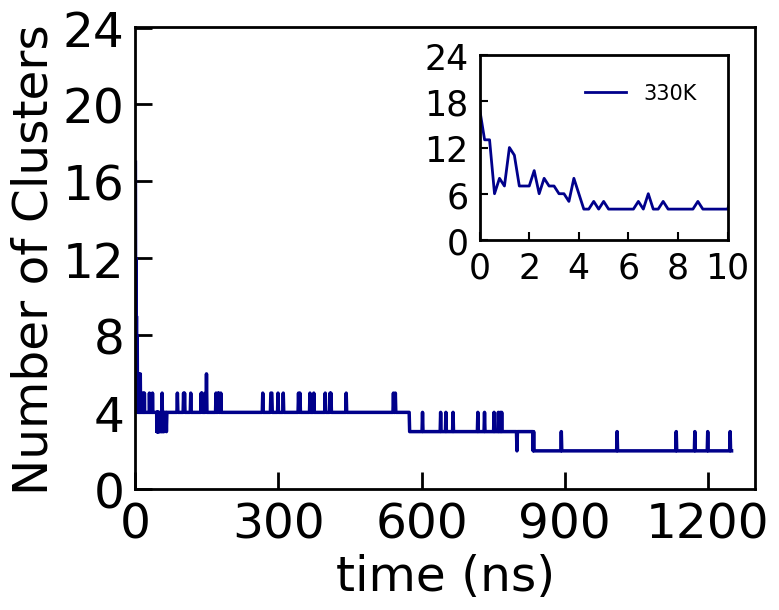

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from pylab import rc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Set plot styling
rc('axes', linewidth=2.0)

# Create main plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(df_330K["time"], df_330K["Clusters"], linestyle='-', color='darkblue', linewidth=2.5)

# Labels and ticks
ax.set_xlabel("time (ns)", fontsize=35, fontname='DejaVu Sans')
ax.set_ylabel("Number of Clusters", fontsize=35, fontname='DejaVu Sans')
ax.set_xlim(0, 1300.01)
ax.set_ylim(0, 24.01)
ax.set_xticks(np.arange(0, 1300.001, 300))
ax.set_yticks(np.arange(0, 24.001, 4))
ax.tick_params(axis='both', which='major', length=12, direction='in', width=2, labelsize=35, pad=8)

# Create inset plot in the upper right corner
ax_inset = inset_axes(ax, width="40%", height="40%", loc='upper right', borderpad=2)

# Plot the same data in the inset, zoomed into the first 50 ns
ax_inset.plot(df_330K["time"], df_330K["Clusters"], linestyle='-', color='darkblue', linewidth=2.0, label="330K")
ax_inset.set_xlim(0, 10)
ax_inset.set_ylim(0, 24)
ax_inset.set_xticks([0, 2, 4, 6, 8, 10])
ax_inset.set_yticks([0, 6, 12, 18, 24])
ax_inset.tick_params(axis='both', which='major', length=6, direction='in', width=1.5, labelsize=25, pad=8)
plt.legend(fontsize=15, bbox_to_anchor=(0.95, 0.95), loc='upper right', edgecolor='white')

# Save and show
plt.savefig("cluster-20per-pluro-330K-with-inset.png", bbox_inches='tight', dpi=500)
plt.show()